# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [3]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [4]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

## Задание 2 Language model (2 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [5]:
model = LanguageModel(train_set)

In [6]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (1.5 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

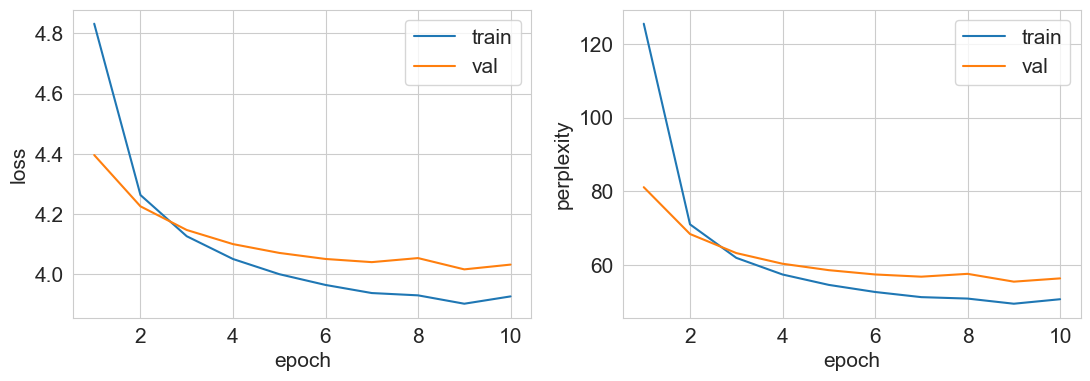

Generation examples:
если ботинки пассажили по себе синимки и буду говорить вдруг осенью и сказали, что они будут девочки на 10 рублей по морде на руке, он не забывала, будто у нее нашь?
матерят вод подходилась.
- уточка- вы упира делаются с геемонкой зале!- ты подумаешь?
в гперзация там гол и рыбака, скупая надевать.
перед тем, что в газет средств те у повезла космонавта вертика в непостиго бездом. спать с правой удержилось! интересно, мото бывшаяся?


In [8]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import torch
from torch import nn
from torch.utils.data import DataLoader
from model import LanguageModel
import train
import importlib
importlib.reload(train)
from train import train

BATCH_SIZE = 64
EMBED_SIZE = 256
HIDDEN_SIZE = 256
RNN_LAYERS = 1
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

model = LanguageModel(
    dataset=train_set,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    rnn_type=nn.RNN,
    rnn_layers=RNN_LAYERS
)

device = device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = None 

train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    num_examples=5 
)

torch.save(model.state_dict(), 'rnn_model_checkpoint.pt')

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

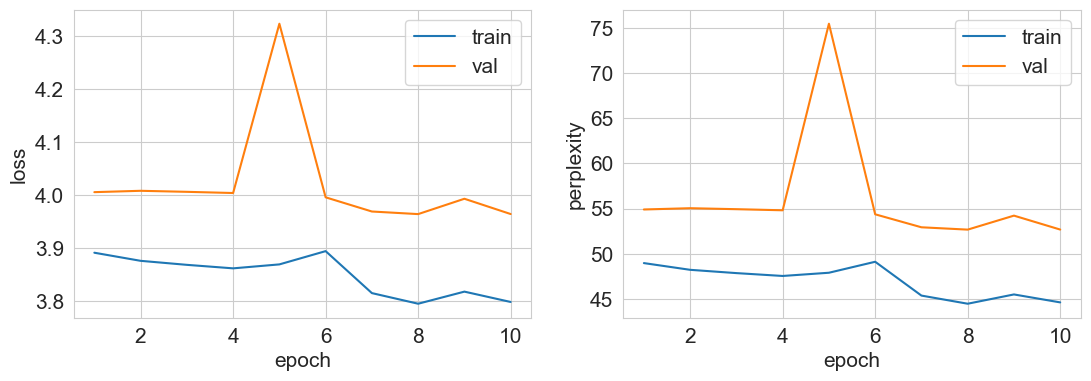

Generation examples:
те же от этого методом любопытства - подъем, но по закону каточки в каниз. сам торгов ухалывалось муж и тревожен, поэтому мужичонки отказались подруге и не знают что он.
- интересно, я уроню тебе достаточно убежден, когда мы не стыдно, и не могу понять, если придется делать когда уезжает фотографию в этом надпись над бог задавает, выиграл радистка...
жизнь, а не туда-то, наверное, если хотите пробавить ее, подождал.
- ты почему-то время чем занимается?- может, враг!- но только у меня в неимеревоониторашек, а если свет считает такое ощущение, что рассчитывает приодельников- одежде, читать?- ну, специально мечтают.
- когда меня пакрата?- местанием устаю культурная поможь?- коробки.


In [9]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

BATCH_SIZE = 64
EMBED_SIZE = 256
HIDDEN_SIZE = 256
RNN_LAYERS = 1
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

model_lstm = LanguageModel(
    dataset=train_set,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    rnn_type=nn.LSTM,
    rnn_layers=RNN_LAYERS
)

device = device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model_lstm.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) 

train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    num_examples=5 
)

torch.save(model_lstm.state_dict(), 'lstm_model_checkpoint.pt')

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [10]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_rnn = LanguageModel(dataset=train_set, embed_size=256, hidden_size=256, rnn_type=nn.RNN)
model_rnn.load_state_dict(torch.load('rnn_model_checkpoint.pt', map_location=device))
model_rnn.to(device)
model_rnn.eval()

model_lstm = LanguageModel(dataset=train_set, embed_size=256, hidden_size=256, rnn_type=nn.LSTM)
model_lstm.load_state_dict(torch.load('lstm_model_checkpoint.pt', map_location=device))
model_lstm.to(device)
model_lstm.eval()

prefixes = ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]
temperatures = [0.3, 0.8, 1.2, 1.8]

print("влияние температуры на генерацию RNN")
for temp in temperatures:
    print(f"Температура = {temp}")
    for pref in prefixes:
        gen = model_rnn.inference(pref, temp=temp)
        print(f"Префикс '{pref}' -> {gen}")
    print()

print("влияние температуры на генерацию LSTM")
for temp in temperatures:
    print(f"Температура = {temp}")
    for pref in prefixes:
        gen = model_lstm.inference(pref, temp=temp)
        print(f"Префикс '{pref}' -> {gen}")
    print()

влияние температуры на генерацию RNN
Температура = 0.3
Префикс '' -> - а я вчера на меня невесту, а ты не представляешь, что ты мне не дарил!
Префикс 'купил мужик шляпу,' -> купил мужик шляпу, а потом пришла к врачу- да, а у вас есть?- нет, я не знаю.
Префикс 'сел медведь в машину и' -> сел медведь в машину и говорит- ну, как же ты знаешь, что ты мне так много думаете, если я тебя не знаю, что ты мне не умеешь делать?
Префикс 'подумал штирлиц' -> подумал штирлиц, а в чем дело, и у нас в стране, не надо.

Температура = 0.8
Префикс '' -> иметь. одни рождаются за то, что голодные люди могут тебе нравится направлять жизненную работу от черепахиа.
Префикс 'купил мужик шляпу,' -> купил мужик шляпу, снял рецепту.- ты меня любишь?
Префикс 'сел медведь в машину и' -> сел медведь в машину и быстро показался в сказке живет? а, что ни заверхит в моем.
Префикс 'подумал штирлиц' -> подумал штирлиц поднимался.

Температура = 1.2
Префикс '' -> украине с корела.- почему?-то отец сегодня хожу и спинуок 

При температуре 1.8 получились совсем бессвязные предложений и слова, это говорит о сильной случайности выбора. При температуре 1.2 так же заметна повышенная случайность, но предложения выглядят все же более связными, одеакр недостаточными для создания смысловой нагрузки. При дальнейшем уменьшении температуры случайность уменьшается сильнее, но в виду посредственной генерации отследить точку потери смысла достаточно трудно. Однако на значении температуры = 0.3 тексты имеют довольно понятную структуру, схожую с обычными анекдотами. С математической точки уменьшение температуры приводит к понижению случайности генерации в виду того, что значения токенов перед подачей в softmax делятся на меньшее число, то есть результат деления возрастает (возрастает разница значений вероятностей) и выбор токена стремится к argmax.

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

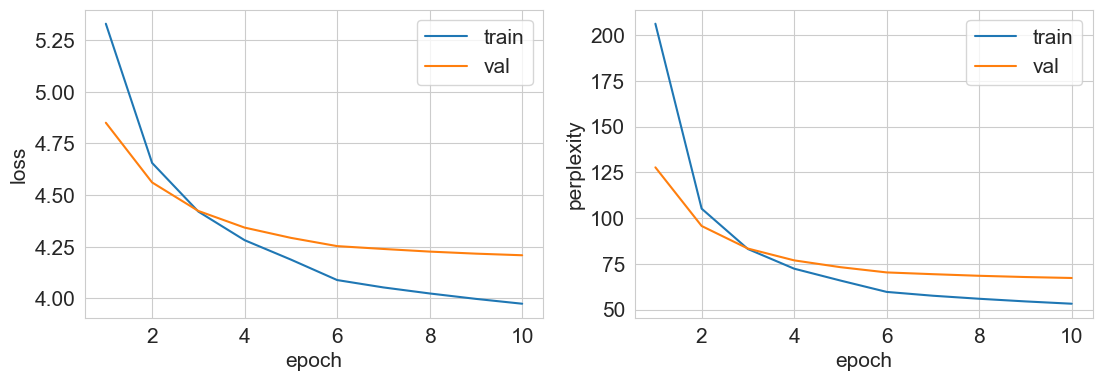

Generation examples:
засыпала на новые дискреной тела. врачи подчине  чрмонят отдохновает сотрудники проступить в думу, номиза на некоторое время 1 ⁇  поехал с суток нищим.
а вы чего золую от хозяина ко отцу еренны кормят бабушку через два точкающего предохму.
требуется счастливого икрой слухи. нора, не может, нормально, но никто не орут.
- в иваново лишили еще клуб?- ну, что, завтра пойду!
когда сал долго кабина дятевонантует - личность!


In [11]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from dataset import TextDataset

train_set_bpe_large = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="bpe_large",
    vocab_size=4000,
    model_type='bpe'
)
valid_set_bpe_large = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="bpe_large",
    vocab_size=4000,
    model_type='bpe'
)

train_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type='unigram'
)
valid_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type='unigram'
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE = 64
EMBED_SIZE = 256
HIDDEN_SIZE = 256
RNN_LAYERS = 1
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

train_loader_bpe = DataLoader(train_set_bpe_large, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_bpe = DataLoader(valid_set_bpe_large, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

model_bpe = LanguageModel(
    dataset=train_set_bpe_large,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    rnn_type=nn.LSTM,
    rnn_layers=RNN_LAYERS
).to(device)

optimizer_bpe = torch.optim.Adam(model_bpe.parameters(), lr=LEARNING_RATE)
scheduler_bpe = torch.optim.lr_scheduler.StepLR(optimizer_bpe, step_size=5, gamma=0.5)

print("BPE vocab_size=4000")
train(
    model=model_bpe,
    optimizer=optimizer_bpe,
    scheduler=scheduler_bpe,
    train_loader=train_loader_bpe,
    val_loader=val_loader_bpe,
    num_epochs=NUM_EPOCHS,
    num_examples=5
)
torch.save(model_bpe.state_dict(), 'bpe_large_checkpoint.pt')

train_loader_uni = DataLoader(train_set_unigram, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_uni = DataLoader(valid_set_unigram, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

model_uni = LanguageModel(
    dataset=train_set_unigram,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    rnn_type=nn.LSTM,
    rnn_layers=RNN_LAYERS
).to(device)

optimizer_uni = torch.optim.Adam(model_uni.parameters(), lr=LEARNING_RATE)
scheduler_uni = torch.optim.lr_scheduler.StepLR(optimizer_uni, step_size=5, gamma=0.5)

print("Unigram vocab_size=4000")
train(
    model=model_uni,
    optimizer=optimizer_uni,
    scheduler=scheduler_uni,
    train_loader=train_loader_uni,
    val_loader=val_loader_uni,
    num_epochs=NUM_EPOCHS,
    num_examples=5
)
torch.save(model_uni.state_dict(), 'unigram_checkpoint.pt')

Качество генерации оказалось хуже. Сранивать по перплексии модели с двумя разными токенизаторами нельзя, так как каждый из токенизаторов создает разные словари, разные токены. То есть в одном из них токеном будет целое слово, в другом - половина этого слова. Таким образом, стохастичность вероятностного пространства возрастает, разные вариации исходов.

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [12]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
import torch

def compute_lsa_similarity(model, valid_dataset, n_components=100, temperature=1.0, max_samples=None):
    device = next(model.parameters()).device
    model.eval()
    val_texts = []
    n_val = len(valid_dataset)
    if max_samples is not None:
        n_val = min(n_val, max_samples)
    for i in tqdm(range(n_val), desc="Decoding val"):
        indices, length = valid_dataset[i] 
        tokens = indices[:length].tolist()
        text = valid_dataset.ids2text(tokens)
        val_texts.append(text)
    
    gen_texts = []
    for _ in tqdm(range(n_val)):
        gen = model.inference(prefix="", temp=temperature)
        gen_texts.append(gen)
    
    corpus = val_texts + gen_texts
    print(f"Размер корпуса: {len(corpus)}")
    
    vectorizer = TfidfVectorizer(max_features=10000, sublinear_tf=True)  # ограничим словарь для скорости
    X = vectorizer.fit_transform(corpus)
    print(f"Размер матрицы: {X.shape}")
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced = svd.fit_transform(X)
    print(f"после SVD: {X_reduced.shape}")
    
    val_vectors = X_reduced[:n_val]
    gen_vectors = X_reduced[n_val:]
    
    similarities = []
    for i, g_vec in enumerate(gen_vectors):
        sim = cosine_similarity([g_vec], val_vectors)[0]
        max_sim = np.max(sim)
        similarities.append(max_sim)

    
    avg_similarity = np.mean(similarities)
    print(f"среднее сходство: {avg_similarity:.4f}")
    return avg_similarity

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_bpe_large = LanguageModel(dataset=train_set_bpe_large, embed_size=256, hidden_size=256, rnn_type=nn.LSTM)
model_bpe_large.load_state_dict(torch.load('bpe_large_checkpoint.pt', map_location=device))
model_bpe_large.to(device).eval()

model_uni = LanguageModel(dataset=train_set_unigram, embed_size=256, hidden_size=256, rnn_type=nn.LSTM)
model_uni.load_state_dict(torch.load('unigram_checkpoint.pt', map_location=device))
model_uni.to(device).eval()

print("BPE")
score_bpe = compute_lsa_similarity(model_bpe_large, valid_set_bpe_large, n_components=100, temperature=1.0, max_samples=500)

print("Unigram")
score_uni = compute_lsa_similarity(model_uni, valid_set_unigram, n_components=100, temperature=1.0, max_samples=500)

print(f"BPE: {score_bpe}")
print(f"Unigram: {score_uni}")

BPE


Decoding val:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Размер корпуса: 1000
Размер матрицы: (1000, 6977)
после SVD: (1000, 100)
среднее сходство: 0.5305
Unigram


Decoding val:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Размер корпуса: 1000
Размер матрицы: (1000, 7129)
после SVD: (1000, 100)
среднее сходство: 0.5335
BPE: 0.5305230841991854
Unigram: 0.5334540153800331


Плюсы метрики: учитывает семантику, понижение размерности позволяет устранять шум (редкие слова, опечатки и тд). Минусы: так как происходит проекция на главные компоненты, то какие-то паттерны будут упущены, что возможно станет проблемой при интерпретации, SVD + tf-idf могут стать проблемой вычислительной сложности.

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

In [14]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from tqdm.notebook import tqdm

def get_lsa_vectors(model, valid_dataset, n_components=100, temperature=1.0, max_samples=500):
    device = next(model.parameters()).device
    model.eval()
    
    val_texts = []
    n_val = min(len(valid_dataset), max_samples)
    for i in tqdm(range(n_val), desc="Decoding val"):
        indices, length = valid_dataset[i]
        tokens = indices[:length].tolist()
        text = valid_dataset.ids2text(tokens)
        val_texts.append(text)
    
    gen_texts = []
    for _ in tqdm(range(n_val), desc="Generating"):
        gen = model.inference(prefix="", temp=temperature)
        gen_texts.append(gen)
    
    corpus = val_texts + gen_texts
    vectorizer = TfidfVectorizer(max_features=10000, sublinear_tf=True)
    X = vectorizer.fit_transform(corpus)
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced = svd.fit_transform(X)
    val_vectors = X_reduced[:n_val]
    gen_vectors = X_reduced[n_val:]
    
    return val_vectors, gen_vectors

def plot_tsne(val_vectors, gen_vectors, model_name, perplexity=30, random_state=42):
    combined = np.vstack([val_vectors, gen_vectors])
    labels = np.array([0] * len(val_vectors) + [1] * len(gen_vectors))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, learning_rate='auto')
    embedded = tsne.fit_transform(combined)
    
    val_embedded = embedded[:len(val_vectors)]
    gen_embedded = embedded[len(val_vectors):]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(val_embedded[:, 0], val_embedded[:, 1], c='blue', label='Validation', alpha=0.6, edgecolors='w', s=50)
    plt.scatter(gen_embedded[:, 0], gen_embedded[:, 1], c='red', label='Generated', alpha=0.6, edgecolors='w', s=50)
    plt.title(f't-SNE визуализация: {model_name}')
    plt.legend()
    plt.xlabel('t-SNE компонента 1')
    plt.ylabel('t-SNE компонента 2')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

Decoding val:   0%|          | 0/500 [00:00<?, ?it/s]

Generating:   0%|          | 0/500 [00:00<?, ?it/s]

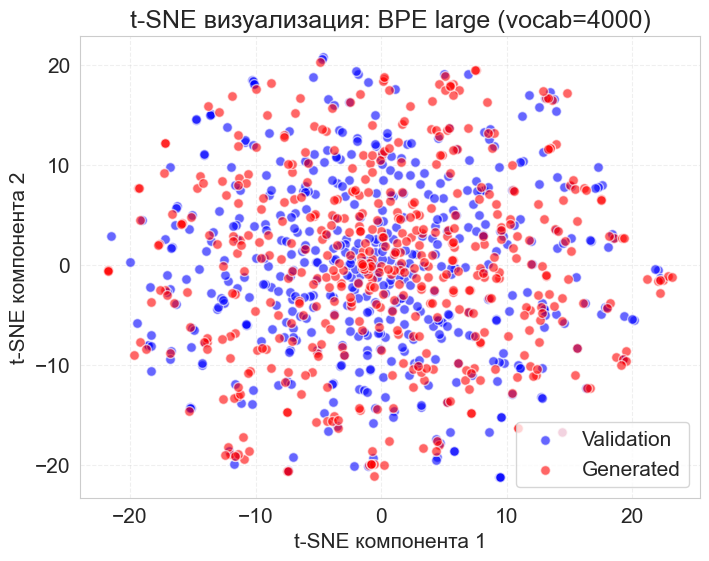

Decoding val:   0%|          | 0/500 [00:00<?, ?it/s]

Generating:   0%|          | 0/500 [00:00<?, ?it/s]

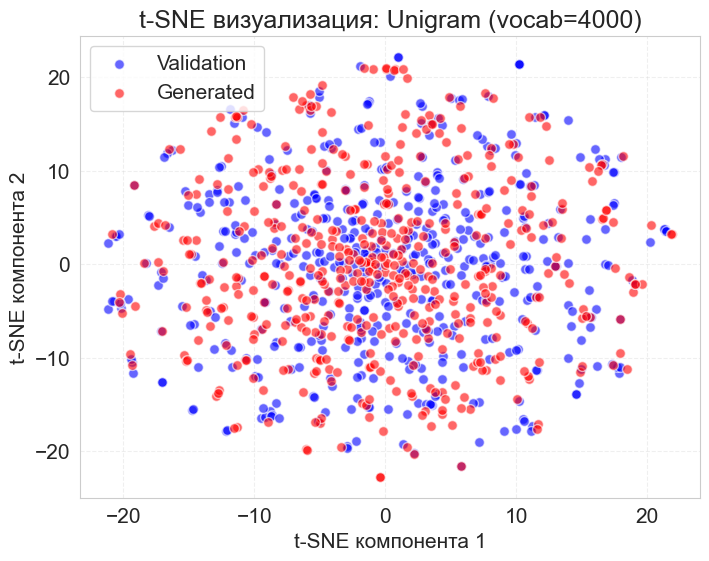

In [16]:
models_info = [
    (model_bpe_large, valid_set_bpe_large, 'BPE large (vocab=4000)'),
    (model_uni, valid_set_unigram, 'Unigram (vocab=4000)')
]

for model, valid_set, name in models_info:
    val_vec, gen_vec = get_lsa_vectors(model, valid_set, n_components=100, max_samples=500)
    plot_tsne(val_vec, gen_vec, model_name=name, perplexity=30)

## Задание 8. ruGPT perplexity (2 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [17]:
%pip install transformers

  Obtaining dependency information for transformers from https://files.pythonhosted.org/packages/b8/88/ae8320064e32679a5429a2c9ebbc05c2bf32cefb6e076f9b07f6d685a9b4/transformers-5.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for tokenizers<=0.23.0,>=0.22.0 from https://files.pythonhosted.org/packages/65/71/0670843133a43d43070abeb1949abfdef12a86d490bea9cd9e18e37c5ff7/tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata
  Obtaining dependency information for typer from https://files.pythonhosted.org/packages/4a/91/48db081e7a63bb37284f9fbcefda7c44c277b18b0e13fbc36ea2335b71e6/typer-0.24.1-py3-none-any.whl.metadata
  Obtaining dependency information for safetensors>=0.4.3 from https://files.pythonhosted.org/packages/5d/e6/ec8471c8072382cb91233ba7267fd931219753bb43814cbc71757bfd4dab/safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata
  Obtaining dependency information for rich>=12.3.0 from https://files.pythonhosted.org/packages/14/25/b208c5683343959b670dc001595f2f3737e051da6

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from tqdm.notebook import tqdm

model_path = "D:/studying/deepLearning/HW3/rugpt3small"
tokenizer = GPT2TokenizerFast.from_pretrained(model_path)
model = GPT2LMHeadModel.from_pretrained(model_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()  

tokenizer.pad_token = tokenizer.eos_token

def calculate_perplexity(text, model, tokenizer, max_length=1024, stride=512):

    encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=1000000)
    seq_len = encodings.input_ids.size(1)
    
    nll_sum = 0.0 
    n_tokens = 0  
    prev_end_loc = 0
    
    for begin_loc in range(0, seq_len, stride):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc 
        
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100
        
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss
        
        num_valid_tokens = (target_ids != -100).sum().item()
        batch_size = target_ids.size(0)
        num_loss_tokens = num_valid_tokens - batch_size 
        
        nll_sum += neg_log_likelihood * num_loss_tokens
        n_tokens += num_loss_tokens
        
        prev_end_loc = end_loc
        if end_loc == seq_len:
            break
    
    avg_nll = nll_sum / n_tokens
    ppl = torch.exp(avg_nll).item()
    return ppl

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: D:/studying/deepLearning/HW3/rugpt3small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
test_text = "Купил мужик шляпу, а она ему как раз."
ppl = calculate_perplexity(test_text, model, tokenizer)
print(f"Перплексия тестового текста: {ppl:.2f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Перплексия тестового текста: 58.22


In [8]:
import torch
import torch.nn as nn
from model import LanguageModel
from dataset import TextDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_set_bpe_large = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe_large", vocab_size=4000, model_type='bpe')
valid_set_bpe_large = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe_large", vocab_size=4000, model_type='bpe')

train_set_unigram = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="unigram", vocab_size=4000, model_type='unigram')
valid_set_unigram = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="unigram", vocab_size=4000, model_type='unigram')

def load_model(checkpoint_path, dataset):
    model = LanguageModel(dataset=dataset, embed_size=256, hidden_size=256, rnn_type=nn.LSTM, rnn_layers=1)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()
    return model

model_bpe_large = load_model('bpe_large_checkpoint.pt', train_set_bpe_large)
model_uni = load_model('unigram_checkpoint.pt', train_set_unigram)

In [9]:
def generate_samples(model, num_samples=100, temperature=1.0):
    texts = []
    for _ in tqdm(range(num_samples), desc="Генерация"):
        texts.append(model.inference(prefix="", temp=temperature))
    return texts

num_samples = 100 
gen_bpe_large = generate_samples(model_bpe_large, num_samples)
gen_unigram = generate_samples(model_uni, num_samples)

Генерация:   0%|          | 0/100 [00:00<?, ?it/s]

Генерация:   0%|          | 0/100 [00:00<?, ?it/s]

In [11]:
import numpy as np

def evaluate_perplexity(texts, model, tokenizer, desc="Оценка"):
    ppls = []
    for text in tqdm(texts, desc=desc):
        ppl = calculate_perplexity(text, model, tokenizer)
        ppls.append(ppl)
    return np.mean(ppls), np.std(ppls) 

print("BPE vocab=4000")
mean_ppl_bpe4k, std_ppl_bpe4k = evaluate_perplexity(gen_bpe_large, model, tokenizer, desc="BPE4k")
print(" Unigram  vocab=4000")
mean_ppl_uni, std_ppl_uni = evaluate_perplexity(gen_unigram, model, tokenizer, desc="Unigram")

BPE vocab=4000


BPE4k:   0%|          | 0/100 [00:00<?, ?it/s]

 Unigram  vocab=4000


Unigram:   0%|          | 0/100 [00:00<?, ?it/s]

In [29]:
import random

for i, text in enumerate(random.sample(gen_unigram, 5), 1):
    print(f"{i}. {text}")

1. первая фраза в боль - подготовка в первую брачную ночь. мы это заснула перестилую женщину, все-таки от них села влив.
2. оружие - это федично, а ведь завтрашеточки прыгали картошку, потому что если соседи будить развод, то чужого мужчины...
3. николая, но остав объясно заводят навстречу! предупреждаю по 100- ⁇ 011 год!водитель туристы- тут упаковки такие клиентку в них обещает!
4. - а зачем стену напьемся безумевного ребенка?- они забыла академи шею, хотела бы и покормить бежать на танец.
5. в носу заходит так много сельсую флосмф-клуб, кричит тонер.через некоторое время жене спрашивает- что я прошу вас правильно?- поеврее яголовки спал.


## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.